In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
URL = 'https://books.toscrape.com'

In [3]:
headers = {
"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
"AppleWebKit/537.36 (KHTML, like Gecko) "
"Chrome/120.0 Safari/537.36"
}

In [4]:
response = requests.get(URL, headers=headers)

In [5]:
response

<Response [200]>

In [6]:
response.text

'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" href

In [7]:
soup = BeautifulSoup(response.text, "html.parser")

In [8]:
soup.texts

In [9]:
books = []
prices = []
ratings = []

In [10]:
for book in soup.select("article.product_pod"):
    title = book.select_one("h3 a")["title"]

    price = book.select_one(".price_color").text

    rating = book.select_one(".star-rating")["class"][1]

    books.append(title)
    prices.append(price)
    ratings.append(rating)


In [11]:
df = pd.DataFrame({
    "Title": books,
    "Price": prices,
    "Rating": ratings
})

In [12]:
print(df)

                                                Title    Price Rating
0                                A Light in the Attic  Â£51.77  Three
1                                  Tipping the Velvet  Â£53.74    One
2                                          Soumission  Â£50.10    One
3                                       Sharp Objects  Â£47.82   Four
4               Sapiens: A Brief History of Humankind  Â£54.23   Five
5                                     The Requiem Red  Â£22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four
9                                     The Black Maria  Â£52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99    Two
11                              Shakespeare's Sonnets  Â£20.66   Four
12                                        Set Me Free  Â£17.46   Five
13  Scott Pilgrim's 

In [13]:
first_para = soup.find('p')
first_para

<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>

In [14]:
for book in soup.select("article.product_pod"):
    print(book.select_one(".price_color"))

<p class="price_color">Â£51.77</p>
<p class="price_color">Â£53.74</p>
<p class="price_color">Â£50.10</p>
<p class="price_color">Â£47.82</p>
<p class="price_color">Â£54.23</p>
<p class="price_color">Â£22.65</p>
<p class="price_color">Â£33.34</p>
<p class="price_color">Â£17.93</p>
<p class="price_color">Â£22.60</p>
<p class="price_color">Â£52.15</p>
<p class="price_color">Â£13.99</p>
<p class="price_color">Â£20.66</p>
<p class="price_color">Â£17.46</p>
<p class="price_color">Â£52.29</p>
<p class="price_color">Â£35.02</p>
<p class="price_color">Â£57.25</p>
<p class="price_color">Â£23.88</p>
<p class="price_color">Â£37.59</p>
<p class="price_color">Â£51.33</p>
<p class="price_color">Â£45.17</p>


In [15]:
df["Price"] = df["Price"].str.replace("Â£","").astype(float)

In [16]:
print(df)

                                                Title  Price Rating
0                                A Light in the Attic  51.77  Three
1                                  Tipping the Velvet  53.74    One
2                                          Soumission  50.10    One
3                                       Sharp Objects  47.82   Four
4               Sapiens: A Brief History of Humankind  54.23   Five
5                                     The Requiem Red  22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  22.60   Four
9                                     The Black Maria  52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  13.99    Two
11                              Shakespeare's Sonnets  20.66   Four
12                                        Set Me Free  17.46   Five
13  Scott Pilgrim's Precious Little Life (Scott 

In [17]:
df.to_csv("books_dataset.csv", index=False)

In [18]:
dt = pd.read_csv("books_dataset.csv")

dt.index = dt.index + 1

In [19]:
dt

,Title,Price,Rating
1,A Light in the Attic,51.77,Three
2,Tipping the Velvet,53.74,One
3,Soumission,50.10,One
4,Sharp Objects,47.82,Four
5,Sapiens: A Brief History of Humankind,54.23,Five
6,The Requiem Red,22.65,One
7,The Dirty Little Secrets of Getting Your Dream...,33.34,Four
8,The Coming Woman: A Novel Based on the Life of...,17.93,Three
9,The Boys in the Boat: Nine Americans and Their...,22.60,Four
10,The Black Maria,52.15,One


In [20]:
# Total number of books in the dataset

total_books = len(dt)
print("Total number of books:", total_books)

Total number of books: 20


In [21]:
# Average price of books 

avg_price = dt["Price"].mean()
print("Average Price:", avg_price)

Average Price: 38.048500000000004


In [22]:
# Highest price books in the dataset

max_price = df["Price"].max()
print("Highest Price:", max_price)

Highest Price: 57.25


In [23]:
# Highest rated books

good_books = dt[(dt["Rating"] == "Four") | (dt["Rating"] == "Five")]
print("Best rated books:", good_books)

Best rated books:                                                 Title  Price Rating
4                                       Sharp Objects  47.82   Four
5               Sapiens: A Brief History of Humankind  54.23   Five
7   The Dirty Little Secrets of Getting Your Dream...  33.34   Four
9   The Boys in the Boat: Nine Americans and Their...  22.60   Four
12                              Shakespeare's Sonnets  20.66   Four
13                                        Set Me Free  17.46   Five
14  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29   Five
15                          Rip it Up and Start Again  35.02   Five


In [24]:
# Highest rated books with affordable prices

rating_map = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}

df["Rating_num"] = df["Rating"].map(rating_map)

In [25]:
best_books = df[(df["Rating_num"] >= 4)].sort_values("Price").head(5)

print(best_books[["Title","Price","Rating"]])

                                                Title  Price Rating
12                                        Set Me Free  17.46   Five
11                              Shakespeare's Sonnets  20.66   Four
8   The Boys in the Boat: Nine Americans and Their...  22.60   Four
6   The Dirty Little Secrets of Getting Your Dream...  33.34   Four
14                          Rip it Up and Start Again  35.02   Five


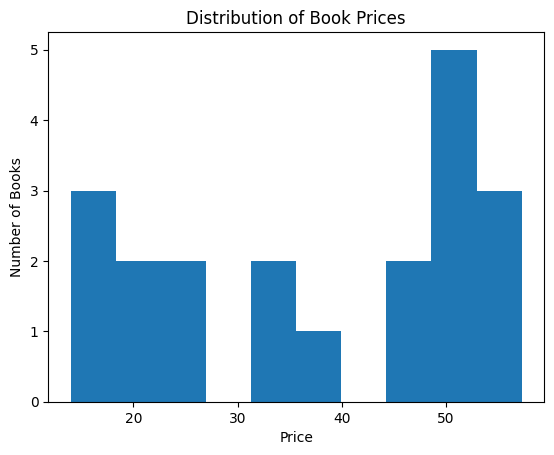

In [26]:
plt.hist(dt["Price"])
plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Number of Books")

plt.show()

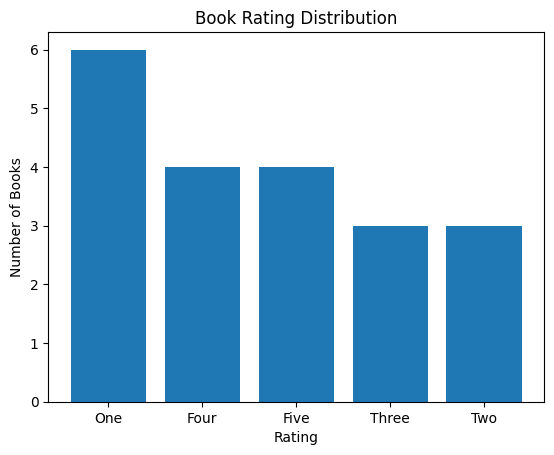

In [27]:
# Count number of books for each rating

rating_counts = df["Rating"].value_counts()

plt.figure()

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

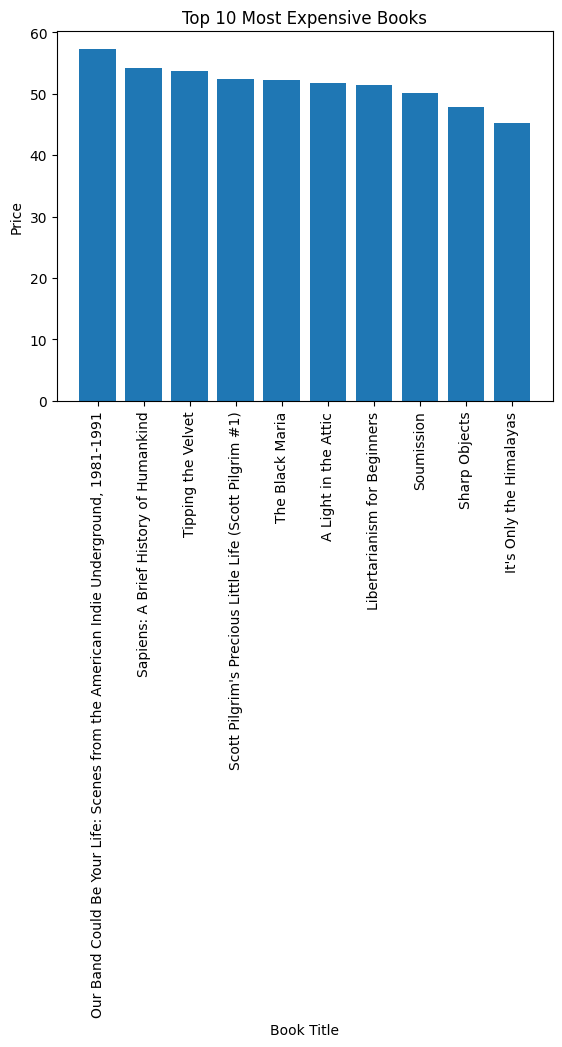

In [28]:
# Top 10 expensive books
top10 = df.sort_values(by="Price", ascending=False).head(10)

plt.figure()

plt.bar(top10["Title"], top10["Price"])

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Book Title")
plt.ylabel("Price")

plt.xticks(rotation=90)

plt.show()

In [29]:
# Correlation between Price and Rating

corr = df[["Price","Rating_num"]].corr()

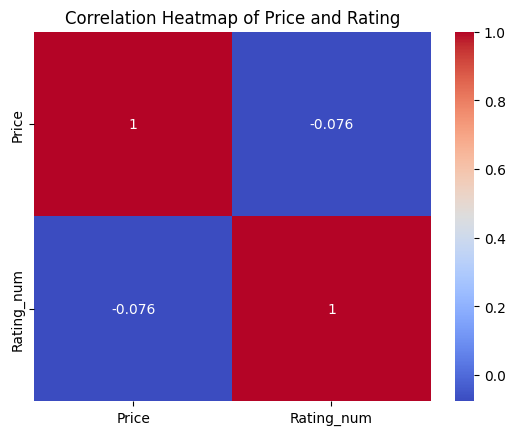

In [30]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Price and Rating")

plt.show()

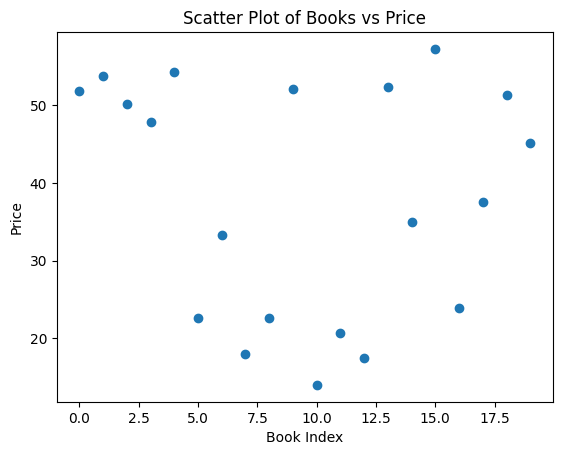

In [31]:
# Book vs Price Distribution

plt.scatter(df.index, df["Price"])

plt.title("Scatter Plot of Books vs Price")
plt.xlabel("Book Index")
plt.ylabel("Price")

plt.show()